# **A. The $\beta$-method for a scalar IVP**

In [ ]:
# import all the packages here

import numpy as np
import matplotlib.pyplot as plt

import warnings


In [ ]:
# Performs integration for the linear IVP given by
#           d/dt u = lambda * u + g(t), u(t_0) = u_0
# using the beta-method
#
# INPUT
# lambda        constant defining the rhs
# g             function defining time-depdendent part of rhs
# tRange        the time interval [t_0, T] of integration
# u0            initial solution at t = tRange(1) (N x 1 array)
# beta          defines the method
# h             the step-size
#
# OUTPUT
# tArray        array containing the time points
# solArray      array containing the solution at each time point
#               (the ith row equals the solution at time tArray(i))

def LinearBetaMethod(Lambda, g, tRange, u0, beta, h):

    # initialize your output based on the number of time steps and on the size
    # of your initial condition; save also the initial condition in th first
    # row of your solArray

    # main loop: separate the cases for explicit and implicit Euler methods
    # you will need a predefined identity matrix for the implicit case

    #define tArray from t0 to T with step size h
    tArray = np.arange(tRange[0], tRange[1]+h, h)
    #define solArray to be a matrix where each row is a solution of the iteration
    solArray = np.zeros((len(tArray), len(u0)))
    #let first row be u0 (ie solution at t0)
    solArray[0] = u0
    #define the identity matrix
    I = np.eye(len(u0))

    for n in range(1, len(tArray)):
        #time and solution from previous iteration
        tn = tArray[n - 1]
        un = solArray[n - 1]

        #compute the new solution
        if beta == 0:
            #explicit case for beta == 0
            Abeta = (1 + (1 - beta) * Lambda * h) / (1- beta * Lambda * h)
            solArray[n] = Abeta * un + ( h * g(tn) )
        else:
            #implicit case for beta =/= 0
            solArray[n] = np.linalg.solve((1 - (beta * h * Lambda) )* I, ((1 + (1 - beta) * h * Lambda) * I) @ un + ( h * g(tn + beta * h)) )


    return tArray, solArray


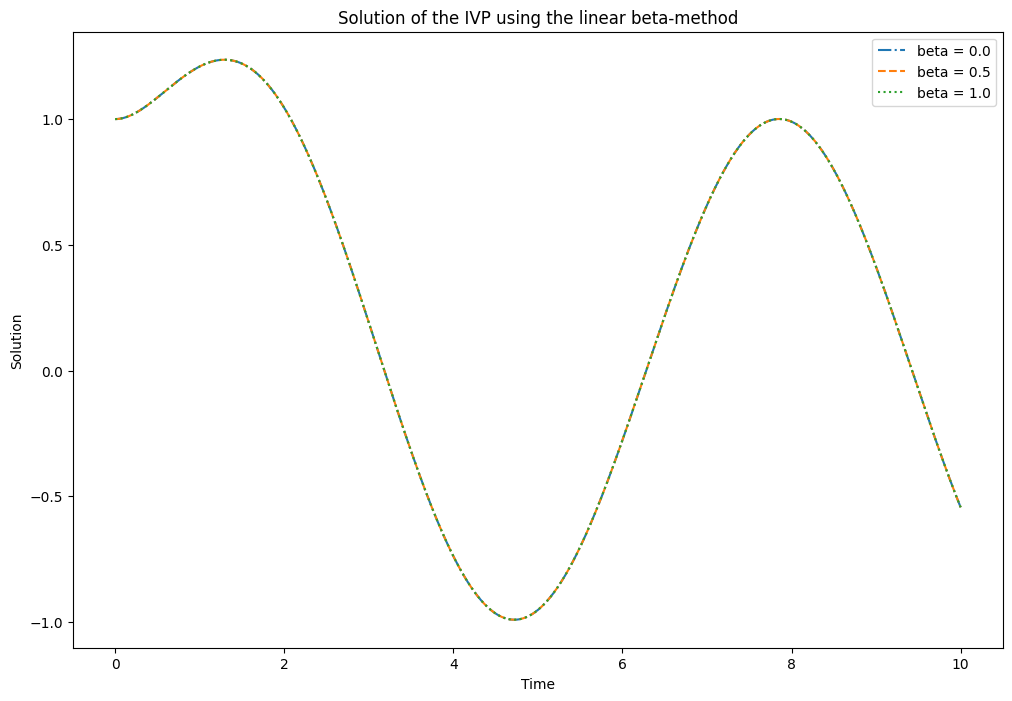

In [ ]:
# Test the linear solver

# set up the inputs for LinearBetaMethod to test it on the problem described at
# page 6 of the pdf, right before the discussion question for different values
# of beta. Use the following time range and initial condition

linestyle = ['-.','--','dotted']
#set up the inputs for LinearBetaMethod
Lambda = -1
g = lambda t: - (Lambda * np.sin(t)) +  np.cos(t)
tRange = np.array([0,10])
y0 = 1.
u0 = np.array([y0])
h = 1e-4

# then create a single figure with 3 plots
# change the line style to make it more readable, as we expect the solutions
# to be very close to each other; here's a possible choice for different line
# styles you can use

plt.figure(figsize=(12, 8))
#loop over the betas
for i in range(3):
    beta = i / 2
    tArray, solArray = LinearBetaMethod(-1., g, tRange, u0, beta, h)
    plt.plot(tArray, solArray, linestyle = linestyle[i], label=f'beta = {beta}')


plt.legend()
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Solution of the IVP using the linear beta-method')
plt.show()


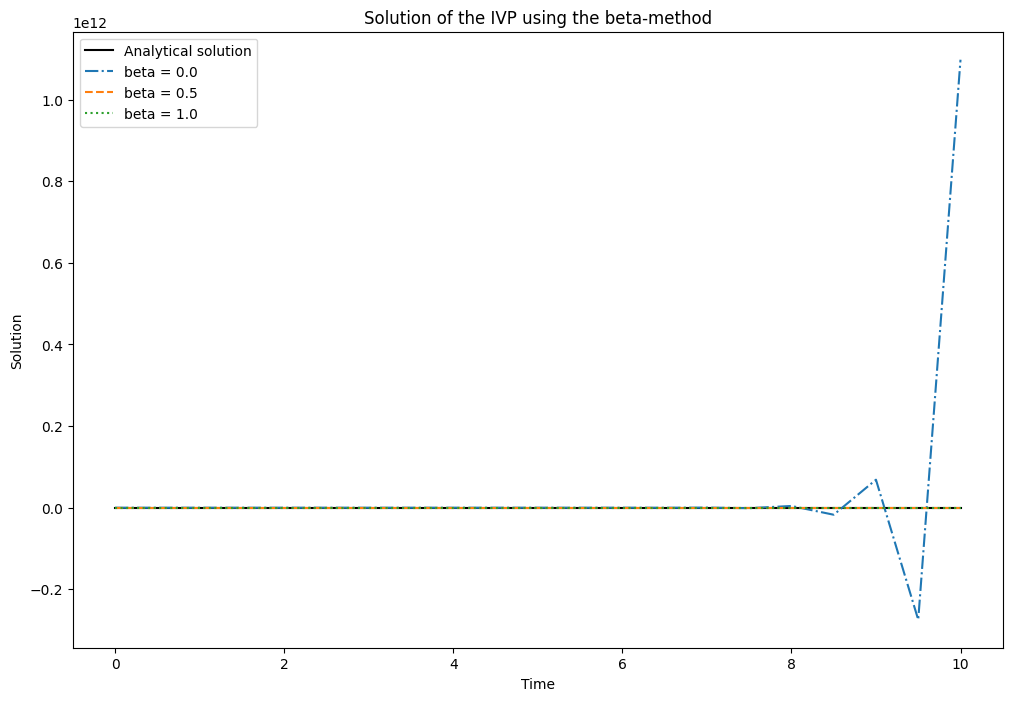

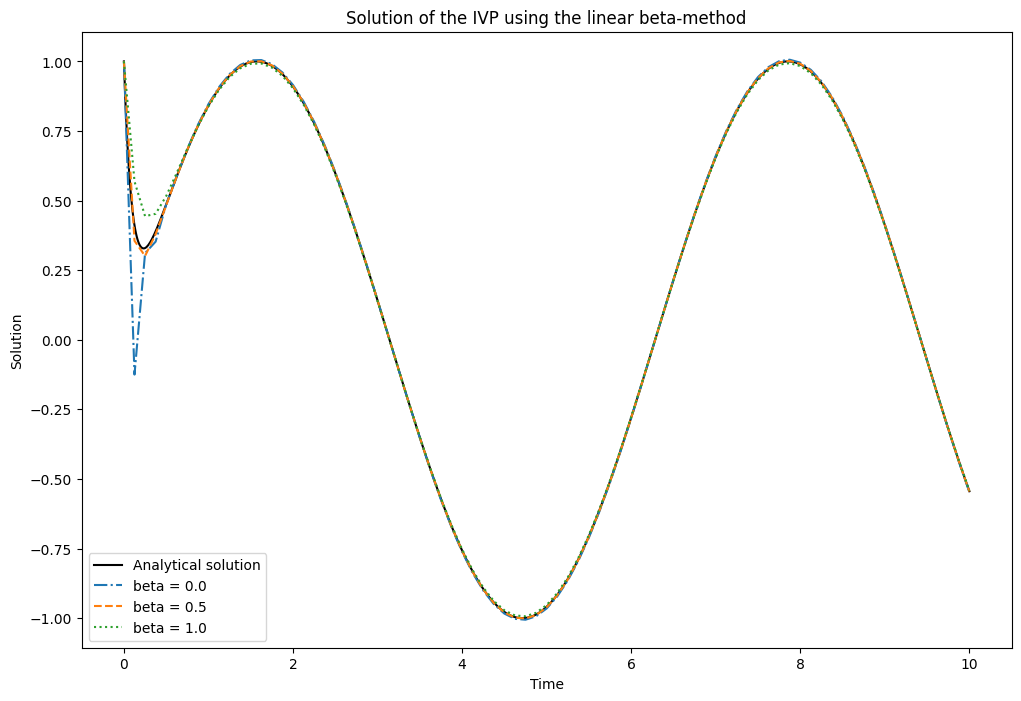

In [ ]:
## Discussion question A.1 (a)-(b)

# set up the new inputs for LinearBetaMethod and the analytical solution
# for each value of h create a figure containing the analytical solution and the
# 3 numerical solutions

# REMINDER: you can directly add plots to the same figure from inside a loop

#set up the inputs for LinearBetaMethod
Lambda = -10
g = lambda t: - (Lambda * np.sin(t)) +  np.cos(t)
tRange = np.array([0,10])
y0 = 1.
u0 = np.array([y0])
h = 0.5

#set up inputs for the analytical solution
y = lambda Lambda, t : np.exp(Lambda * t) + np.sin(t)


plt.figure(figsize=(12, 8))
#plot the analytical solution
plt.plot(np.linspace(0, 10, int(1e3 + 1)), y(-10, np.linspace(0, 10, int(1e3 + 1))), 'k', label='Analytical solution')

#loop over the betas and plot the numerical solutions
for i in range(3):
    beta = i / 2
    tArray, solArray = LinearBetaMethod(Lambda, g, tRange, u0, beta, 0.5)
    plt.plot(tArray, solArray, linestyle = linestyle[i], label=f'beta = {beta}')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Solution of the IVP using the beta-method')
plt.show()

# (b)
#repeat the above but for h=0.125
h = 0.125


plt.figure(figsize=(12, 8))
#plot the analytical solution
plt.plot(np.linspace(0, 10, int(1e3 + 1)), y(-10, np.linspace(0, 10, int(1e3 + 1))), 'k', label='Analytical solution')

#loop over the betas and plot the numerical solutions
for i in range(3):
    beta = i / 2
    tArray, solArray = LinearBetaMethod(-10, g, tRange, u0, beta, 0.125)
    plt.plot(tArray, solArray, linestyle = linestyle[i], label=f'beta = {beta}')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Solution of the IVP using the linear beta-method')
plt.show()


# **B. Accuracy of the $\beta$-method**

<ipython-input-5-4617426c6f3e>:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error[j] = np.abs(solArray[j] - y(Lambda, tArray[j]))


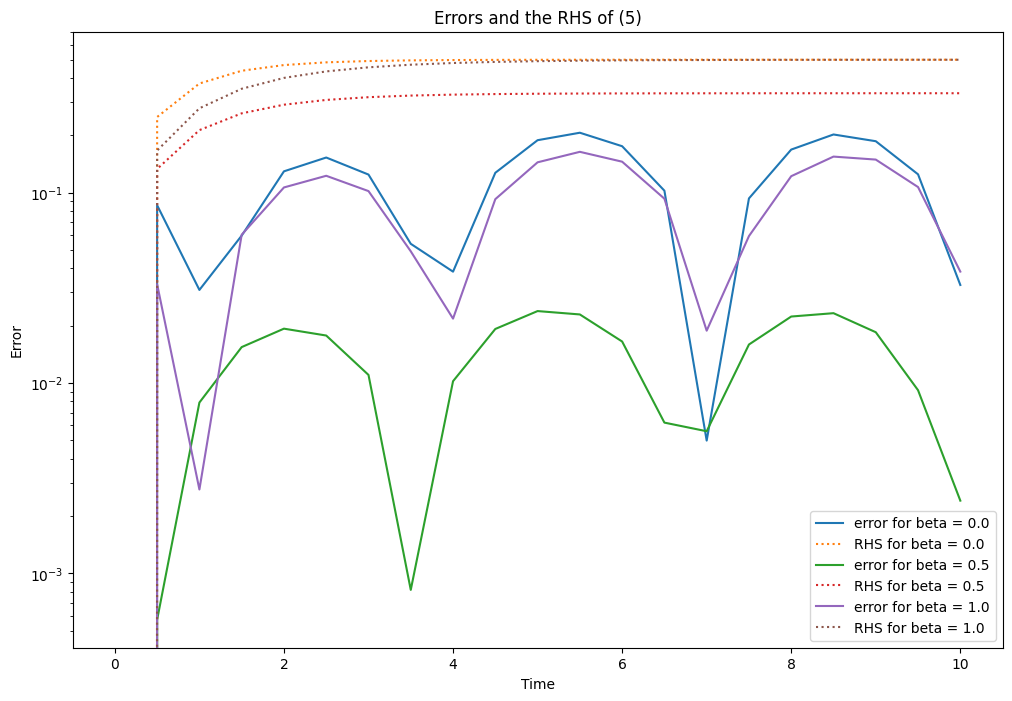

In [ ]:
## Discussion question B.1(a)

# you can define the amplification factor A as a function of multiple variables,
#       A = lambda h, Lambda, beta: ...

# REMINDER: the expression for T_max changes considerably with beta and
# determines the right-hand side that you have to plot

# IMPORTANT: the output of this cell consists of a single figure with 6 plots,
# 3 for the numerical errors and 3 for the right-hand sides, in a semilogy scale

#set up the inputs for LinearBetaMethod
Lambda = -1
g = lambda t: - (Lambda * np.sin(t)) +  np.cos(t)
tRange = np.array([0,10])
y0 = 1.
u0 = np.array([y0])
#u0 = np.array([[1]])
h = 0.5

#define the amplification factor A
A = lambda h, Lambda, beta : (1 + (( 1 - beta) * h * Lambda)) / (1 - (beta * Lambda * h))

#define TMax
def TMax(Lambda ,h):
  if beta == 1/2:
    tau = (h**3) * ((1 + (np.abs(Lambda)) ** 3) / 24 ) + ( (5/8) * ( h ** 3) * np.abs(Lambda) * (1 + (np.abs(Lambda)) ** 2) )
  else:
    tau = (h**2) * (1 + (np.abs(Lambda))**2) / 2
  return tau

#plot the error between the exact solution and the approximate solutions as well as the RHS of (5)
plt.figure(figsize = (12,8))
#loop over the betas
for i in range(3):
    beta = i / 2
    tArray, solArray = LinearBetaMethod(Lambda, g, tRange, u0, beta, 0.5)
    #initialise the error and RHS arrays
    error = np.zeros(len(tArray))
    RHS = np.zeros(len(tArray))
    #compute error and RHS component-wise
    for j in range(len(tArray)):
        error[j] = np.abs(solArray[j] - y(Lambda, tArray[j]))
        RHS[j] = ( TMax(Lambda, 0.5) / np.abs(1 - (Lambda * h * beta))) * ((1 - (np.abs(A(0.5, Lambda, beta) ** j))) / (1 - np.abs(A(0.5, Lambda, beta))))

    plt.semilogy(tArray, error, label =f'error for beta = {beta}'  )
    plt.semilogy(tArray, RHS, linestyle = linestyle[2], label =f'RHS for beta = {beta}'  )

plt.legend()
plt.xlabel('Time')
plt.ylabel('Error')
plt.title('Errors and the RHS of (5)')
plt.show()


<ipython-input-6-deec1ceebf35>:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error[l] = np.abs(solArray[-1] - y(Lambda, tArray[-1]))


The slope for beta= 0.0 is 0.9290231740217129
The slope for beta= 0.5 is 1.9440842544877104
The slope for beta= 1.0 is 1.0135535114870498


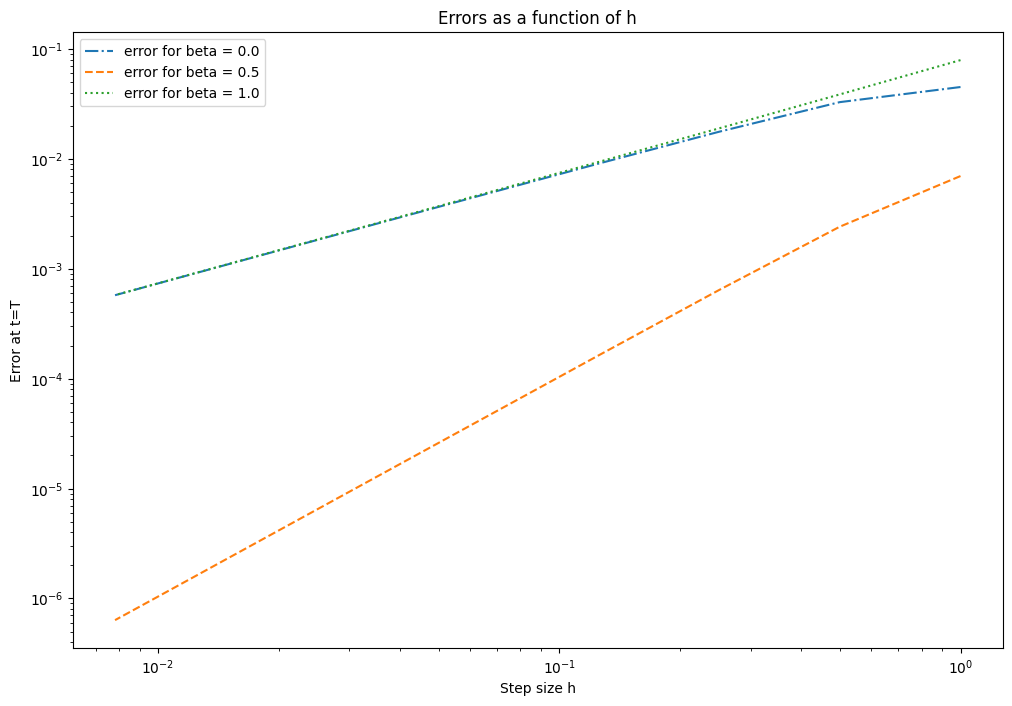

In [ ]:
## Discussion question B.1(b)

# the idea is completely analogous to the previous question, so you can reuse a
# lot of code

# set up the corrct values for h

# IMPORTANT: the output of this cell consists of a print out of the slopes
# and a single figure with the 3 error plots in a loglog scale

#set up the inputs for LinearBetaMethod
Lambda = -1
g = lambda t: - (Lambda * np.sin(t)) +  np.cos(t)
tRange = np.array([0, 10])
y0 = 1.
u0 = np.array([y0])
#u0 = np.array([[1]])

#set up inputs for the analytical solution
y = lambda Lambda, t : np.exp(Lambda * t) + np.sin(t)

#define the amplification factor A
A = lambda h, Lambda, beta : (1 + (( 1 - beta) * h * Lambda)) / (1 - (beta * Lambda * h))

#initialise the h and error arrays
h = np.zeros(8)
error = np.zeros(8)

#plot the error at t = T for β = 0, 0.5, 1 as function of h
plt.figure(figsize = (12,8))
#loop over the betas
for i in range(3):
    beta = i / 2
    #loop over the different values of h
    for l in range(8):
        h[l] = 2 ** (-l)
        tArray, solArray = LinearBetaMethod(Lambda, g, tRange, u0, beta, h[l])
        #compute the error
        error[l] = np.abs(solArray[-1] - y(Lambda, tArray[-1]))

    plt.loglog(h, error, linestyle= linestyle[i], label =f'error for beta = {beta}' )
    #compute the slopes of each of the three lines
    slope, intercept =np.polyfit(np.log(h), np.log(error), 1)
    print(f'The slope for beta= {beta} is {slope}')

plt.legend()
plt.xlabel('Step size h')
plt.ylabel('Error at t=T')
plt.title('Errors as a function of h')
plt.show()


## **C. The $\beta$-method for a system of IVP**

In [ ]:
## paste here your version of newton() from Unit 2

def fpIterator(phi, x0, tol=1e-12, maxit=50):

    # initialize your output variables here (x, success, errEst, xHist)
    x = x0
    success = False
    errEst = np.empty(maxit)
    xHist = np.empty((maxit + 1, len(x0)))
    xHist[0,:] = x0

    # loop (at most maxit iterations) to find the root
    for i in range(maxit):
        # compute new guess for the root
        xNew = phi(xHist[i,:])
        # update array with solutions per iterations
        xHist[i+1,:] = xNew

        # compute error at current iteration
        error = np.linalg.norm(xNew - x)
        # update array with error estimate per iterations
        errEst[i] = error

        # checking for convergence, i.e. check if the error at the current iteration reached the tolerance
        if error < tol:
            # final x value
            x = xHist[i+1,:]
            # update success
            success = True
            # cut xHist up to and including the (i+1)st elements (since first entry is x0)
            xHist = xHist[:i+2,:]
            # cut errEst up to and including the ith element
            errEst = errEst[:i+1]
            break

        # update the previous iteration of x
        x = xNew

    return x, success, errEst, xHist

def newton(f, df, x0, tol=1e-12, maxit=50):

    # implementation should be trivial using your fpIterator with a properly
    # implemented function phi

    if len(x0) == 1:
        # define Newton phi
        phiN = lambda x: x - ( f(x) / df(x) )
    else:
        phiN = lambda x: x - ( np.linalg.solve(df(x), f(x)) )

    # use fpIterator with phiN as input
    x, success, errEst, xHist = fpIterator(phiN, x0, tol, maxit)


    return x, success, errEst, xHist


In [ ]:
# Performs integration for the system of IVPs given by
#           d/dt u = f(t, u), u(t_0) = u_0
# using the beta-method
# INPUT
# f             the right-hand side function, the output should be a
#               N x 1 array where N is the number of unknowns
# tRange        the time interval [t_0, T] of integration
# u0            initial solution at t = tRange(1) (N x 1 array)
# df            a function that evaluates the Jacobian matrix of f
# beta          defines the method
# h             the step-size
#
# OUTPUT
# tArray        array containing the time points
# solArray      array containing the solution at each time point
#               (the ith row equals the solution at time tArray(i))


def BetaMethod(f, tRange, u0, df, beta, h):

    # initialize your output as for the linear version and set up th newton()
    # inputs

    #define tArray from t0 to T with step size h
    tArray = np.arange(tRange[0], tRange[1]+h, h)
    #define solArray to be a matrix where each row is a solution of the iteration
    solArray = np.zeros((len(tArray), len(u0)))
    #let first row be u0 (ie solution at t0)
    solArray[0] = u0
    #define the identity matrix
    I = np.eye(len(u0))
    nIterations = 0

    tol = 1e-12
    maxit=50

    # main loop: separate the cases for explicit and implicit Euler methods
    for n in range(1, len(tArray)):
        #time and solution from previous iteration
        tn = tArray[n - 1]
        un = solArray[n - 1]

        #explicit case for beta == 0
        if beta == 0:
            solArray[n] = un + (h * f(tn, un))
        #implicit case
        else:
        # for the implicit method you will need to define F, DF and X0 for newton()

        # both F and DF have to be function handles
        #       F  = lambda x: ...
        #       DF = lambda x: ...
            tnBeta = tn + (beta * h)
            F = lambda x: x - un - (h * f(tnBeta, ((1 - beta) * un) + (beta * x )))
            DF = lambda x : I - ( h * beta * df( ( (1 - beta) * un) + (beta * x)) )
            X0 = un
            solArray[n], success, errEst, solHist = newton(F, DF, X0, tol=1e-12, maxit=50)

        # remember to raise error and break the loop if newton() does not converge
        # e.g.
        #
        # import warnings
        # if not success:
        #   warnings.warn('Newton method has failed after %d iterations (tolerance was %9.2e)\n' % (maxit, tol))
        #   break

            if not success:
                warnings.warn('Newton method has failed after %d iterations (tolerance was %9.2e)\n' % (maxit, tol))
                #tArray = tArray[:n+1]
                #solArray = solArray[:n+1,:]
                break

    return tArray, solArray


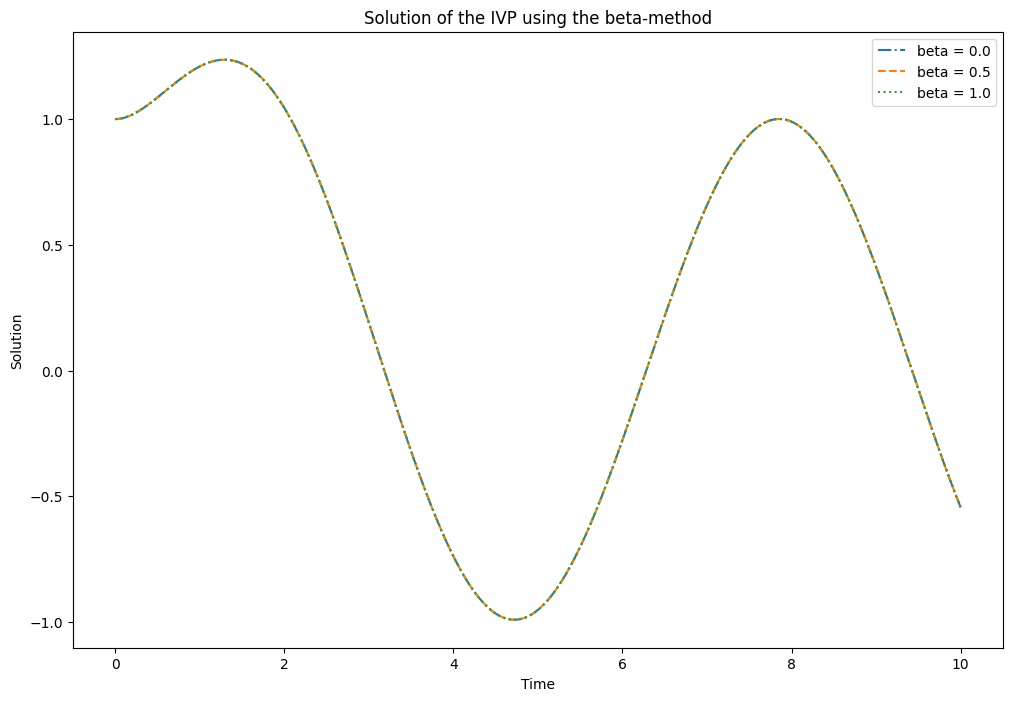

In [ ]:
# Consider the linear test problem (6) and verify that the solution has not changed compared
# to the one obtained from linearBetaMethod for a few values of β. Is important to check that he
# Newton iterations converge in one step since the problem is linear, and if β = 0 in a non-linear
# case.

linestyle = ['-.','--','dotted']
# set up inputs for BetaMethod
Lambda = -1
tRange = np.array([0,10])
y0 = 1.
u0 = np.array([y0])
h = 1e-4

f = lambda t, y: ( Lambda * (y - np.sin(t)) ) + np.cos(t)
df = lambda y: Lambda


plt.figure(figsize=(12, 8))
for i in range(3):
    beta = i / 2
    tArray, solArray = BetaMethod(f, tRange, u0, df, beta, h)
    plt.plot(tArray, solArray, linestyle = linestyle[i], label=f'beta = {beta}')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Solution of the IVP using the beta-method')
plt.show()


In [ ]:
# INPUT
# x             position of dynamic body
# G             gravitational constant
# M             mass of attracting body
#
# OUTPUT
# g             gravitational acceleration

def gravAccF(x, G, M):

    # use the formula in equation (9)
    g = - ( (G * M) / (np.linalg.norm(x) ** 3) ) * x

    return g


In [ ]:
# INPUT
# x             position of dynamic body
# G             gravitational constant
# M             mass of attracting body
#
# OUTPUT
# jacG          Jacobian of gravitational acceleration w.r.t. position x

def gravAccJac(x, G, M):
    # use the formula in equation (11)
    jacG = ( (G * M) / (np.linalg.norm(x) ** 3) ) * (- np.eye(3) + ( 3 * (np.matmul(x, np.transpose(x)) / np.linalg.norm(x) ** 2) ) )

    return jacG


<ipython-input-8-6336862d9b40>:68: UserWarning: Newton method has failed after 50 iterations (tolerance was  1.00e-12)

  warnings.warn('Newton method has failed after %d iterations (tolerance was %9.2e)\n' % (maxit, tol))


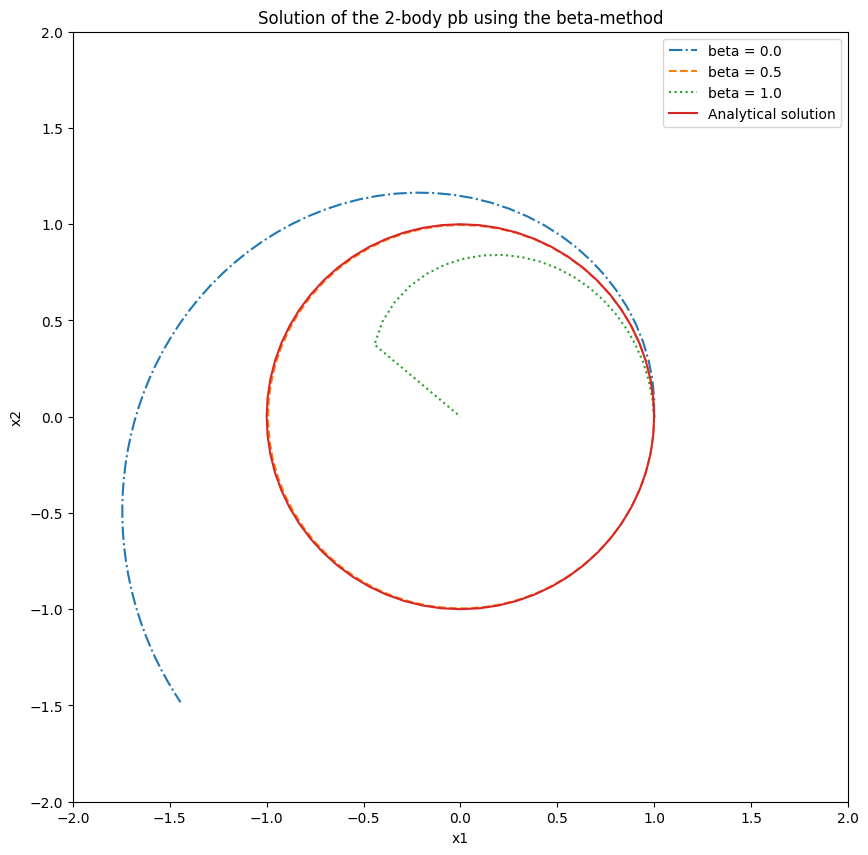

In [ ]:
## Discussion question C.1

# set up all the parameters given in the pdf for the 2 body problem
R = 1
M = 1
G = 4 * (np.pi ** 2)
Omega = np.sqrt( (G * M) / (R ** 3) )

# then define all the inputs for BetaMethod() and the exact solution function
xExact = lambda t: R * np.array([np.cos(Omega * t), np.sin(Omega * t), 0])
xExactDer = lambda t: R * np.array([-Omega * np.sin(Omega * t), Omega * np.cos(Omega * t), 0])

x0 = xExact(0)
v0 = xExactDer(0)
y0 = np.concatenate((v0, x0)) #y = [v,x] from tutorial
#u0 = np.array([y0])

# handle; use the following syntax to define function handles
#       f = lambda var1, var2, var3: ...
# the code will be considerably more readable
f2 = lambda t, y: np.concatenate((gravAccF(y[3:], G, M), y[:3])) # where y = [v, x]
df2 = lambda y: np.block([ [np.zeros((3,3)), gravAccJac(y[3:], G, M)], [np.eye(3), np.zeros((3,3))] ])# jacobian Jf wrt y

# other parameter needed: beta, h, time range
T = ( 2 * np.pi ) / Omega
tRange = np.array([0, T])
h =  (2 ** (-6)) * T

# finally solve the system using BetaMethod() and plot (x_1(t), x_2(t)) for
# the 3 values of beta in the samee figure together with the exact solution

plt.figure(figsize = (10, 10))
#loop over the betas
for i in range(3):
    beta = i / 2
    tArray, solArray = BetaMethod(f2, tRange, y0, df2, beta, h)
    plt.plot(solArray[:, 3], solArray[:, 4], linestyle=linestyle[i], label=f'beta = {beta}')

#plot the analytical solution
x1 = lambda t: R * np.cos(Omega * t)
x2 = lambda t: R * np.sin(Omega * t)
plt.plot(x1(np.arange(tRange[0], tRange[1]+h, h)), x2(np.arange(tRange[0], tRange[1]+h, h)), label = f'Analytical solution')

plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.legend()
#plt.grid(True)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Solution of the 2-body pb using the beta-method')
plt.show()


<ipython-input-8-6336862d9b40>:68: UserWarning: Newton method has failed after 50 iterations (tolerance was  1.00e-12)

  warnings.warn('Newton method has failed after %d iterations (tolerance was %9.2e)\n' % (maxit, tol))


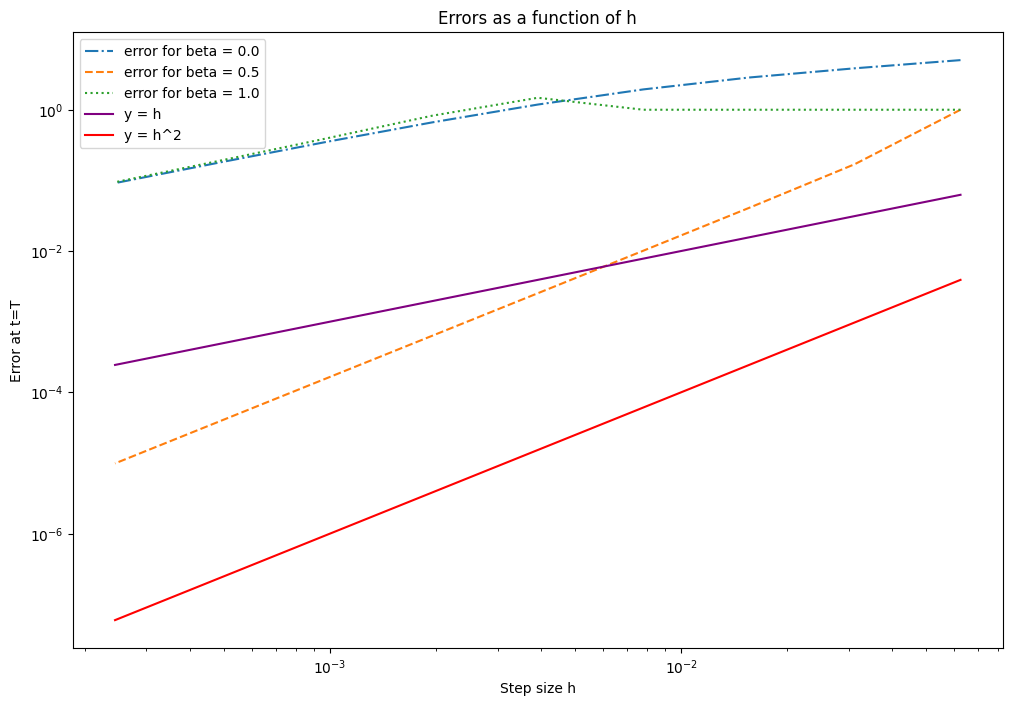

In [ ]:
## Discussion question C.2

# set up the inputs of BetaMethod and initialize the error variable

# set up all the parameters given in the pdf for the 2 body problem
R = 1
M = 1
G = 4 * (np.pi ** 2)
Omega = np.sqrt( (G * M) / (R ** 3) )

# then define all the inputs for BetaMethod() and the exact solution function
xExact = lambda t: R * np.array([np.cos(Omega * t), np.sin(Omega * t), 0])
xExactDer = lambda t: R * np.array([-Omega * np.sin(Omega * t), Omega * np.cos(Omega * t), 0])

x0 = xExact(0)
v0 = xExactDer(0)
y0 = np.concatenate((v0, x0)) #y = [v,x] from tutorial
#u0 = np.array([y0])

f2 = lambda t, y: np.concatenate((gravAccF(y[3:], G, M), y[:3])) # where y = [v, x]
df2 = lambda y: np.block([ [np.zeros((3,3)), gravAccJac(y[3:], G, M)], [np.eye(3), np.zeros((3,3))] ])# jacobian Jf wrt y

# other parameter needed: beta, h, time range
T = ( 2 * np.pi ) / Omega
tRange = np.array([0, T])

#initialise the rror variable and the h and h^2 arrays
h = np.zeros(9)
hSquared = np.zeros(9)
error = np.zeros(9)

# solve the system using different values of beta and h and store the error

#plot the 2-norm of the error at t = T for each value of β as function of h

# IMPORTANT: the output of this cell is a single figure with 6 plots, 3 for the
# error and 3 for the corresponding functions to compare the slopes (for beta
# equal to 0 and 1 they will be the same)

plt.figure(figsize = (12,8))
#loop over the betas
for i in range(3):
    beta = i / 2
    #loop over the values of h and store these values of h
    for l in range(4,13):
        h[l-4] = (2 ** (-l) ) * T
        hSquared[l-4] = h[l-4] ** 2
        tArray, solArray = BetaMethod(f2, tRange, y0, df2, beta, h[l-4])
        #store the error (of position x)
        error[l-4] = np.linalg.norm(solArray[-1, 3:] - xExact(tArray[-1]))
    plt.loglog(h, error, linestyle= linestyle[i], label =f'error for beta = {beta}' )

#include the functions y = h and y = h^2 for comparison of the slopes
plt.loglog(h, h, label = 'y = h', color = 'purple'  )
plt.loglog(h, hSquared, label = 'y = h^2', color = 'red'  )

plt.legend()
#plt.grid(True)
plt.xlabel('Step size h')
plt.ylabel('Error at t=T')
plt.title('Errors as a function of h')
plt.show()
